In [1]:
import json
import glob
import matplotlib.pyplot as plt
import numpy as np
import os
from plot_progress import gather_metrics
from parse_levels import find_levels_in_configs, find_levels_in_configs_glob
import pandas as pd
import matplotlib.ticker as ticker
import re
workspace_base_path = lambda item: os.path.join('/checkpoint/maui/zhaobc/scientist/workspace', item)

In [2]:
base_file_path = '../workspace_templates/nanogpt_speedrun/record_{i}/train_gpt2.py'
base_metrics = '../workspace_templates/nanogpt_speedrun/record_{i}/results.json'

In [3]:
# final json structure
# {
#     "record_id": {
#         "human": {
#             "code": "...",
#             "metrics": {
#                 "val_loss": ...,
#                 "train_time": ...,
#             }
#         },
#         "next_human": {
#             "code": "...",
#             "metrics": {
#                 "val_loss": ...,
#                 "train_time": ...,
#             }
#         },
#         "ai_repro": {
#             "code": "...",
#             "metrics": {
#                 "val_loss": ...,
#                 "train_time": ...,
#             }
#         },
#         "ai_negative": {
#             "code": "...",
#             "metrics": {
#                 "val_loss": ...,
#                 "train_time": ...,
#             }
#         },
#     }
# }

In [4]:
final_json = {}
for record_id in range(1, 19):
    human_code = open(base_file_path.format(i=record_id), 'r').read()
    next_human_code = open(base_file_path.format(i=record_id+1), 'r').read()
    metrics = json.load(open(base_metrics.format(i=record_id), 'r'))
    next_metrics = json.load(open(base_metrics.format(i=record_id+1), 'r'))
    final_json[record_id] = {
        "human": {
            "code": human_code,
            "metrics": {
                "val_loss": metrics['metrics']['val_loss'],
                "train_time": metrics['metrics']['train_time'],
            }
        },
        "next_human": {
            "code": next_human_code,
            "metrics": {
                "val_loss": next_metrics['metrics']['val_loss'],
                "train_time": next_metrics['metrics']['train_time'],
            }
        }
    }

In [5]:
ori_results = find_levels_in_configs_glob(
    [
        '/checkpoint/maui/zhaobc/scientist/workspace/record_*_20250422_*',
        # '/checkpoint/maui/zhaobc/scientist/workspace/record_*_20250405_*'
        # '/checkpoint/maui/zhaobc/scientist/workspace/record_1[2-8]_20250412_*',
        #  '/checkpoint/maui/zhaobc/scientist/workspace/record_*_20250408_*',
        # '/checkpoint/maui/zhaobc/scientist/workspace/record_*_20250405_*'
        # '/checkpoint/maui/zhaobc/scientist/workspace/record_1[2-8]_20250409_*',
    ]
)

Found 96 directories


In [6]:
from parse_levels import filter_folder_info

In [7]:

folder_info = ori_results

In [8]:
o3_bon = filter_folder_info(folder_info, [
   ('levels', 125),  # level 125 stands for using pseudo-code (1), text (2), and paper (5)
   ('runner', 'bon'),
   ('model', 'o3-mini'),
])

In [9]:
def process_metrics(record):
    for k, v in record.items():
        metrics = gather_metrics(
            workspace_base_path(k),
            metrics=['val_loss', 'train_time'],
            workspace_template_path=os.path.join(
                'workspace_templates', 
                'nanogpt_speedrun', 
                f"record_{v['record']}"
            )
        )
        metrics.loc[metrics['val_loss'] >= 3.29, 'train_time'] = np.nan
        record[k]['metrics'] = metrics
    return record


In [10]:
o3_bon = process_metrics(o3_bon)

In [11]:
final_json[9]['human']['metrics']['train_time']

505531

In [12]:

def convert_to_dict(record, keep_dim=False):
    results = {}
    for k, v in record.items():
        # record_num = int(k.split('-')[-1])
        ## the +1 here is because the process is 0-indexed but record number is 1-indexed
        # results[record_num + 1] = v['metrics']['train_time'].min()
        # record_num = k.split('_2025')[0].split('_')[-1]
        pattern = r"^record_(\d+)_"
        match = re.match(pattern, k)
        record_num = int(match.group(1))
        if keep_dim:
            results[record_num] = v['metrics']['train_time'].tolist()
        else:
            results[record_num] = v['metrics']['train_time'].min()
    return results


In [13]:
o3_bon_results = convert_to_dict(o3_bon, keep_dim=True)
o3_bon_results_print = convert_to_dict(o3_bon, keep_dim=False)

In [14]:

human_train_time_dict = {
    1: 2968348,
    2: 2209926,
    3: 1386147,
    4: 1301740,
    5: 949528,
    6: 766259,
    7: 773072,
    8: 662205,
    9: 505531,
    10: 477150,
    11: 442985,
    12: 317839,
    13: 289805,
    14: 273107,
    15: 241463,
    16: 232971,
    17: 220374,
    18: 211840,
    19: 199442
}

In [15]:
def compute_gap_in_percentage_list(
        model_time, 
        human_time=human_train_time_dict, 
    ):
    gaps = {}
    for k, v in human_time.items():
        if (k + 1) not in human_time:
            continue
        gaps[k] = v - human_time[k+1]
    
    recovered_times = {}
    for k, vs in model_time.items():
        recovered_times[k] = []
        for v in vs:
            recovered_time = human_time[k] - v
            recovered_times[k].append(recovered_time)

    recovered_gap_in_percentage = {}
    for k, vs in recovered_times.items():
        if (k + 1) not in gaps:
            continue
        recovered_gap_in_percentage[k] = []
        for v in vs:
            recovered_gap_in_percentage[k].append(v / gaps[k] if gaps[k] > 0 else 0)
        recovered_gap_in_percentage[k] = np.array(recovered_gap_in_percentage[k])
        # replace nan with 0
        recovered_gap_in_percentage[k][np.isnan(recovered_gap_in_percentage[k])] = 0

    return recovered_gap_in_percentage



In [16]:
o3_bon_gap = compute_gap_in_percentage_list(o3_bon_results)

In [17]:
o3_bon_gap

{7: array([ 0.        , -0.0905319 , -0.03797343,  0.65924035,  0.66501303,
        -0.20092543, -0.10592873, -0.12181262, -0.14459668, -0.11475913,
        -0.19545942, -0.11226966, -0.18511369, -0.17024904,  0.54494124,
         0.55363634,  0.63262287,  0.545744  ,  0.53189858,  0.61936374,
         0.57100851,  0.49515185,  0.51295697,  0.65131193,  0.65181704,
         0.66465224,  0.6086933 ,  0.65875328,  0.60305591,  0.55782153,
         0.6575807 , -0.12669234,  0.        ,  0.        ,  0.        ,
         0.        ,  0.54256902,  0.        ,  0.59086112,  0.57675413,
         0.56578603,  0.59362119,  0.63027772,  0.63094519,  0.64537689,
         0.60574382,  0.59978172,  0.59808599,  0.63310092,  0.59983584,
         0.5793789 ,  0.59229527,  0.57577999,  0.62528074,  0.6195712 ,
         0.68609234,  0.61152552,  0.59282744,  0.64662163,  0.55823645,
         0.60405711,  0.57836868,  0.64842559,  0.65465828,  0.65620067,
         0.67390657,  0.59026581,  0.66345261,  

In [18]:
def compute_gap_in_percentage(
        model_time, 
        human_time=human_train_time_dict, 
    ):
    gaps = {}
    for k, v in human_time.items():
        if (k + 1) not in human_time:
            continue
        gaps[k] = v - human_time[k+1]
    
    recovered_times = {}
    for k, v in model_time.items():
        recovered_time = human_time[k] - v
        recovered_times[k] = recovered_time

    recovered_gap_in_percentage = {}
    for k, v in recovered_times.items():
        if (k + 1) not in gaps:
            continue
        recovered_gap_in_percentage[k] = v / gaps[k] if gaps[k] > 0 else 0

    return recovered_gap_in_percentage



In [19]:
o3_bon_gap_print = compute_gap_in_percentage(o3_bon_results_print)

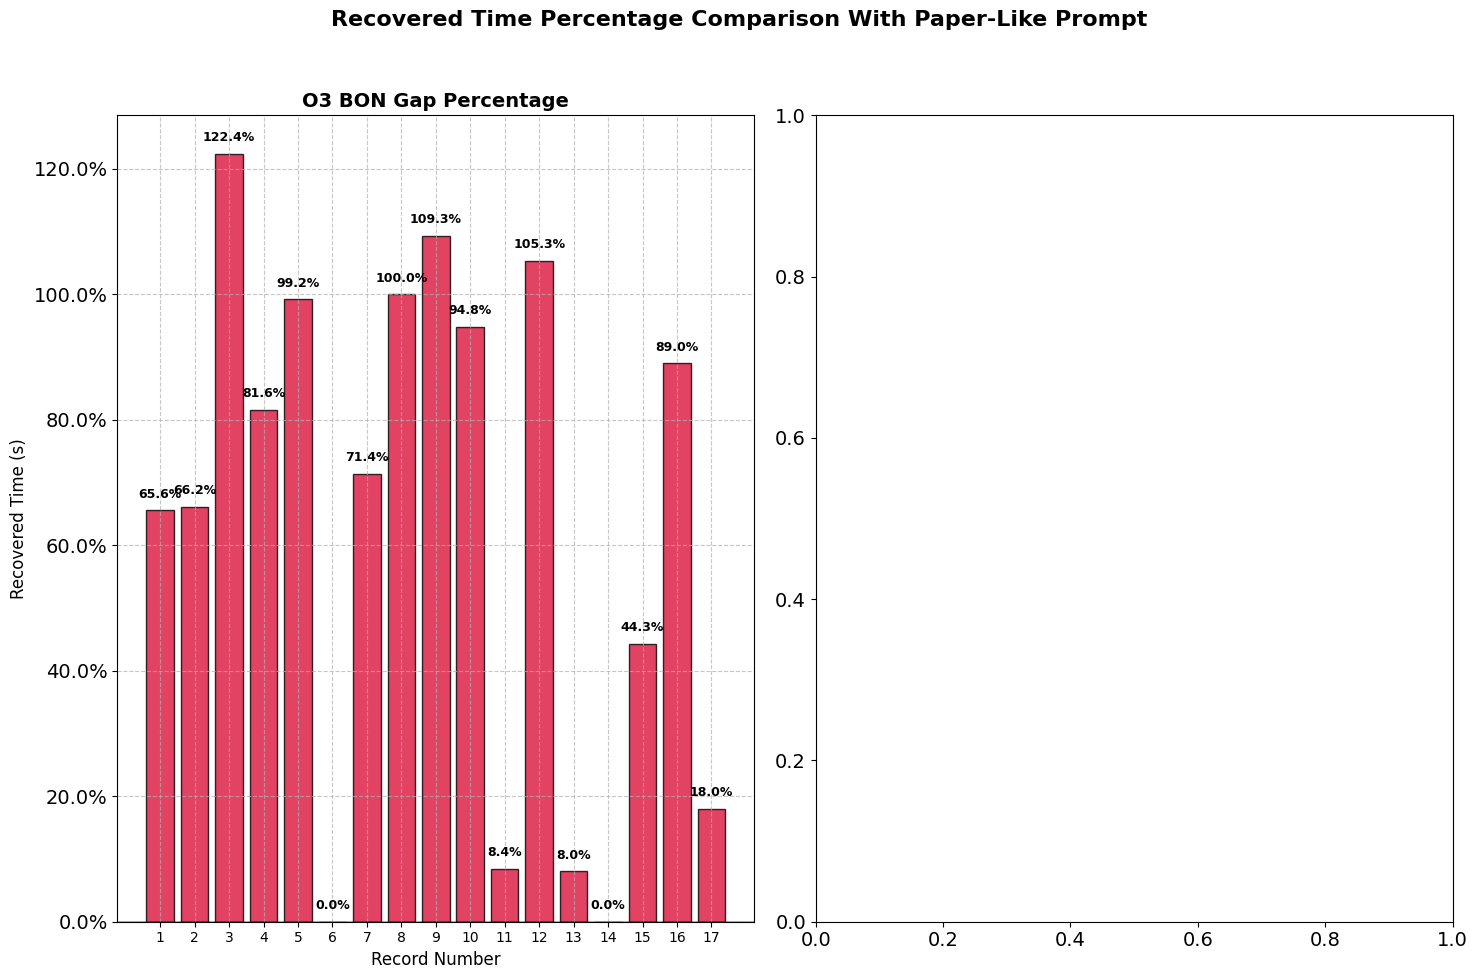

In [20]:
# Create a list of dictionaries and their titles with different colors
data_dicts = [
    (o3_bon_gap_print, "O3 BON Gap Percentage", 'crimson'),
]

# Create a 2x2 subplot layout
fig, axs = plt.subplots(1, 2, figsize=(15, 10))
# axs = axs.flatten()  # Flatten the 2x2 array to make indexing easier

# Create a barplot for each dictionary
for i, (data_dict, title, color) in enumerate(data_dicts):
    # Sort the dictionary by keys
    sorted_items = sorted(data_dict.items(), key=lambda x: int(x[0]))
    keys = [item[0] for item in sorted_items]
    values = [item[1] for item in sorted_items]
    
    # Create the barplot with the specified color
    bars = axs[i].bar(range(len(keys)), values, color=color, edgecolor='black', alpha=0.8)
    
    # Add title and labels
    axs[i].set_title(title, fontsize=14, fontweight='bold')
    axs[i].set_xlabel('Record Number', fontsize=12)
    axs[i].set_ylabel('Recovered Time (s)', fontsize=12)
    
    # Ensure all xticks are shown
    axs[i].set_xticks(range(len(keys)))
    axs[i].set_xticklabels(keys, fontsize=10)
    
    # Add grid for better readability
    axs[i].grid(True, linestyle='--', alpha=0.7)
    
    # Add a horizontal line at y=0
    axs[i].axhline(y=0, color='black', linestyle='-', alpha=0.3)
    
    # Format y-axis as percentage
    axs[i].yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: '{:.1%}'.format(y)))
    
    # Annotate the values on top of the bars
    for bar in bars:
        height = bar.get_height()
        if height >= 0:
            y_pos = height + 0.02
        else:
            y_pos = height - 0.05
        axs[i].text(
            bar.get_x() + bar.get_width()/2.,
            y_pos,
            '{:.1%}'.format(height),
            ha='center', 
            fontsize=9,
            fontweight='bold',
            color='black'
        )

# Add a main title for the figure
fig.suptitle('Recovered Time Percentage Comparison With Paper-Like Prompt', fontsize=16, fontweight='bold', y=0.98)

# Adjust layout
plt.tight_layout(rect=[0, 0, 1, 0.96])  # Make room for the suptitle

# Show the plot
plt.show()

In [21]:
o3_bon_gap

{7: array([ 0.        , -0.0905319 , -0.03797343,  0.65924035,  0.66501303,
        -0.20092543, -0.10592873, -0.12181262, -0.14459668, -0.11475913,
        -0.19545942, -0.11226966, -0.18511369, -0.17024904,  0.54494124,
         0.55363634,  0.63262287,  0.545744  ,  0.53189858,  0.61936374,
         0.57100851,  0.49515185,  0.51295697,  0.65131193,  0.65181704,
         0.66465224,  0.6086933 ,  0.65875328,  0.60305591,  0.55782153,
         0.6575807 , -0.12669234,  0.        ,  0.        ,  0.        ,
         0.        ,  0.54256902,  0.        ,  0.59086112,  0.57675413,
         0.56578603,  0.59362119,  0.63027772,  0.63094519,  0.64537689,
         0.60574382,  0.59978172,  0.59808599,  0.63310092,  0.59983584,
         0.5793789 ,  0.59229527,  0.57577999,  0.62528074,  0.6195712 ,
         0.68609234,  0.61152552,  0.59282744,  0.64662163,  0.55823645,
         0.60405711,  0.57836868,  0.64842559,  0.65465828,  0.65620067,
         0.67390657,  0.59026581,  0.66345261,  

In [22]:
from collections import defaultdict

In [23]:
# for each record, get the idx of the entry that has the highest gap (if higher than 0.5)
# and also get the idx of the entry that has the lowest gap (if lowest is 0.0 then get that one)
highest_for_each_record = defaultdict(list) # save entries of k: (idx, gap)
lowest_for_each_record = defaultdict(list)
for k, vs in o3_bon_gap.items():
    for idx, v in enumerate(vs):
        if v > 0.5:
            if not len(highest_for_each_record[k]):
                highest_for_each_record[k] = (idx, v)
            elif v > highest_for_each_record[k][1]:
                highest_for_each_record[k] = (idx, v)
        if v <= 0.0:
            if not len(lowest_for_each_record[k]):
                lowest_for_each_record[k] = (idx, v)
            elif v < lowest_for_each_record[k][1]:
                lowest_for_each_record[k] = (idx, v)
# if any of them is empty, then just get the highest one for highest, and the lowest one for lowest
for k, vs in o3_bon_gap.items():
    if not len(highest_for_each_record[k]):
        high_idx = np.argmax(vs)
        highest_for_each_record[k] = (high_idx, vs[high_idx])
    if not len(lowest_for_each_record[k]):
        low_idx = np.argmin(vs)
        lowest_for_each_record[k] = (low_idx, vs[low_idx])


In [24]:
for record_id in sorted(highest_for_each_record.keys()):
    print(record_id)
    print(f"highest: {highest_for_each_record[record_id]}")
    print(f"lowest: {lowest_for_each_record[record_id]}")
    print()

1
highest: (63, 0.6560635108158782)
lowest: (1, 0.0)

2
highest: (69, 0.6615597144379742)
lowest: (0, -0.11502478213210096)

3
highest: (0, 1.2239269254919616)
lowest: (16, -1.047673771132726)

4
highest: (45, 0.8161902490545467)
lowest: (0, 0.0)

5
highest: (72, 0.991635246550153)
lowest: (56, -0.6422908402403025)

6
highest: (0, 0)
lowest: (0, 0)

7
highest: (73, 0.7141620139446364)
lowest: (5, -0.20092543317668918)

8
highest: (1, 0.9997319274416943)
lowest: (0, 0.0)

9
highest: (41, 1.0932313871956592)
lowest: (0, 0.0)

10
highest: (86, 0.9481633250402459)
lowest: (0, 0.0)

11
highest: (69, 0.08405382513224553)
lowest: (8, -0.6180221501286497)

12
highest: (73, 1.0530070628522508)
lowest: (18, -93.4614396803881)

13
highest: (76, 0.08006946939753264)
lowest: (15, -0.40639597556593604)

14
highest: (0, 0.0)
lowest: (6, -0.4382821387940842)

15
highest: (80, 0.4430051813471503)
lowest: (72, -0.2943947244465379)

16
highest: (61, 0.8901325712471223)
lowest: (45, -39.37961419385568)

1

In [25]:
recordid2folder = {}
for record_folder, record_info in o3_bon.items():
    recordid2folder[record_info['record']] = record_folder


In [26]:
recordid2folder

{7: 'record_7_20250422_112158_2071473-2071466-6',
 14: 'record_14_20250422_112536_2071552-2071548-3',
 5: 'record_5_20250422_112158_2071471-2071466-4',
 10: 'record_10_20250422_112158_2071466-2071466-9',
 1: 'record_1_20250422_112158_2071467-2071466-0',
 13: 'record_13_20250422_112536_2071551-2071548-2',
 3: 'record_3_20250422_112158_2071469-2071466-2',
 16: 'record_16_20250422_112536_2071554-2071548-5',
 8: 'record_8_20250422_112158_2071474-2071466-7',
 12: 'record_12_20250422_112536_2071550-2071548-1',
 17: 'record_17_20250422_112536_2071555-2071548-6',
 2: 'record_2_20250422_112158_2071468-2071466-1',
 11: 'record_11_20250422_112536_2071549-2071548-0',
 18: 'record_18_20250422_112536_2071548-2071548-7',
 9: 'record_9_20250422_112158_2071475-2071466-8',
 15: 'record_15_20250422_112536_2071553-2071548-4',
 4: 'record_4_20250422_112158_2071470-2071466-3',
 6: 'record_6_20250422_112158_2071472-2071466-5'}

In [27]:
highest_for_each_record, lowest_for_each_record

(defaultdict(list,
             {7: (73, 0.7141620139446364),
              5: (72, 0.991635246550153),
              10: (86, 0.9481633250402459),
              1: (63, 0.6560635108158782),
              3: (0, 1.2239269254919616),
              16: (61, 0.8901325712471223),
              8: (1, 0.9997319274416943),
              12: (73, 1.0530070628522508),
              2: (69, 0.6615597144379742),
              9: (41, 1.0932313871956592),
              4: (45, 0.8161902490545467),
              14: (0, 0.0),
              13: (76, 0.08006946939753264),
              17: (71, 0.18033747363487226),
              11: (69, 0.08405382513224553),
              15: (80, 0.4430051813471503),
              6: (0, 0)}),
 defaultdict(list,
             {7: (5, -0.20092543317668918),
              14: (6, -0.4382821387940842),
              5: (56, -0.6422908402403025),
              10: (0, 0.0),
              1: (1, 0.0),
              13: (15, -0.40639597556593604),
              3: (16, 

In [28]:
workspace_base_path(recordid2folder[1])

'/checkpoint/maui/zhaobc/scientist/workspace/record_1_20250422_112158_2071467-2071466-0'

In [29]:
# get the code for each highest and lowest
for record_id, (idx, gap) in highest_for_each_record.items():
    folder = recordid2folder[record_id]
    folder_path = workspace_base_path(folder)
    v_highest = open(os.path.join(folder_path, f'v_{idx}', f'train_gpt2.py'), 'r').read()
    metrics_highest = json.load(open(os.path.join(folder_path, f'v_{idx}', 'results.json'), 'r'))
    idx_lowest = lowest_for_each_record[record_id][0]
    v_lowest = open(os.path.join(folder_path, f'v_{idx_lowest}', f'train_gpt2.py'), 'r').read()
    metrics_lowest = json.load(open(os.path.join(folder_path, f'v_{idx_lowest}', 'results.json'), 'r'))

    final_json[record_id].update({
        'ai_repro': {
            'code': v_highest,
            'metrics': {
                'val_loss': metrics_highest['metrics']['val_loss'],
                'train_time': metrics_highest['metrics']['train_time'],
            }
        },
        'ai_negative': {
            'code': v_lowest,
            'metrics': {
                'val_loss': metrics_lowest['metrics']['val_loss'],
                'train_time': metrics_lowest['metrics']['train_time'],
            }
        }
    })

In [31]:
final_json[1]

{'human': {'code': 'import os\nimport sys\nimport uuid\nimport math\nimport glob\nfrom dataclasses import dataclass\n\nimport numpy as np\nimport torch\nfrom torch import nn\nimport torch.nn.functional as F\nimport torch._inductor.config as config\nfrom torch.nn.parallel import DistributedDataParallel as DDP\nfrom torch.distributed import init_process_group, destroy_process_group\n\nwith open(sys.argv[0]) as f:\n    code = f.read()\n\n# -----------------------------------------------------------------------------\n# PyTorch nn.Module definitions for the GPT-2 model\n\ndef rmsnorm(x0, eps=1e-6):\n    x = x0.float()\n    x = x * torch.rsqrt(x.pow(2).mean(-1, keepdim=True) + eps)\n    return x.type_as(x0)\n\nclass CausalSelfAttention(nn.Module):\n\n    def __init__(self, config):\n        super().__init__()\n        assert config.n_embd % config.n_head == 0\n        # key, query, value projections for all heads, but in a batch\n        self.c_attn = nn.Linear(config.n_embd, 3 * config.n_e

In [33]:
with open('/checkpoint/maui/zhaobc/scientist/code_analysis.json', 'w') as f:
    json.dump(final_json, f, indent=4)
